# Introduction

This notebook is dedicated to fitting experimental Ramsey data using a Master equation that incorporates both magnetic and electric noise. The decay observed in the data typically follows the form $(1/T_2^*)^{exponent}$. The goal is to find both values for $T_2^*$ and the $exponent$ for electric and magnetic noise. By modeling this decay, we can gain insights into the underlying noise processes affecting the system.

# Imports

In [2]:
import numpy as np
from scipy.linalg import expm
from lmfit import Model, Parameters, minimize
import matplotlib.pyplot as plt
import qcodes as qc
from HighSpinModel import *
from HighSpin import *
import qutip as qt

## helper functions

In [3]:
def contrast(f):
    """
    Compute the contrast of the signal.

    Parameters:
    f (numpy array): The signal data.

    Returns:
    float: The contrast of the signal.
    """
    return (np.max(f, axis=0) - np.min(f, axis=0)) / 2

def ExponentialSineFit(t, amplitude, frequency, phase_offset, tau, alpha, offset):
    """
    Fit function combining an exponential decay and a sine wave.

    Parameters:
    t (numpy array): Time data.
    amplitude (float): Amplitude of the sine wave.
    frequency (float): Frequency of the sine wave.
    phase_offset (float): Phase offset of the sine wave.
    tau (float): Decay constant.
    alpha (float): Exponent for the decay.
    offset (float): Constant offset.

    Returns:
    numpy array: The fitted data.
    """
    sin_part = amplitude*np.sin(2*np.pi*frequency*t+phase_offset)
    exp_part = np.exp(-(t/tau)**alpha)
    return exp_part*sin_part+offset

# Build model

This section sets up the model parameters and prepares the data for fitting. 

In [4]:
I = [HighSpin(1/2), HighSpin(3/2), HighSpin(5/2), HighSpin(7/2)]

t = np.concatenate([np.logspace(-1, 2, 300), np.linspace(100.1, 1400, 300)])

zcatdecay = [[] for _ in range(len(I))]
xcatdecay = [[] for _ in range(len(I))]
ramseydecay = [[] for _ in range(len(I))]

for s in range(len(I)):
    model = HighSpinModel(I[s]) 
    model.T2Mstar = 200
    model.T2Estar = 164
    model.alphaM = 1.2
    model.alphaE = 1.45
    modRam = model.Ramsey(t, 0)
    decayify = lambda state: I[s].rho(state)[:, np.newaxis] * modRam

    zcat = np.zeros(int(2 * I[s].I + 1))
    zcat[0] = 1 / np.sqrt(2)
    zcat[-1] = 1 / np.sqrt(2)

    zcatdecay[s].append(I[s].paritymeas(decayify(zcat), 'z'))

    Rx = expm(-1j * I[s].x * np.pi / 2)
    Ry = expm(-1j * I[s].x * np.pi / 2)
    xcat = Rx[:, 0] @ expm(-1j * I[s].z**2 * np.pi / 2)
#     xcat = Ry @ zcat

    xcatdecay[s].append(I[s].paritymeas(decayify(xcat), 'x'))

    ramseydecay[s].append(I[s].ramseymeas(decayify(Ry[:, 0])))



In [5]:
def exponential_decay(t, T2star, amplitude, offset, alpha):
    return amplitude * np.exp(-(t / T2star)**alpha) + offset

exp_model = Model(exponential_decay)
params = Parameters()
params.add('T2star', value=1.0, min=0.1, max=1000.0)
params.add('amplitude', value=1.0, min=0.1)
params.add('offset', value=0.0)
params.add('alpha', value=1.0, min=0.1, max=2.0)

In [6]:
NMR_transition_labels = [
    r"$-7/2 \leftrightarrow -5/2$",
    r"$-5/2 \leftrightarrow -3/2$",
    r"$-3/2 \leftrightarrow -1/2$",
    r"$-1/2 \leftrightarrow +1/2$",
    r"$+1/2 \leftrightarrow +3/2$",
    r"$+3/2 \leftrightarrow +5/2$",
    r"$+5/2 \leftrightarrow +7/2$"
]

# Simulate 

## z-cats

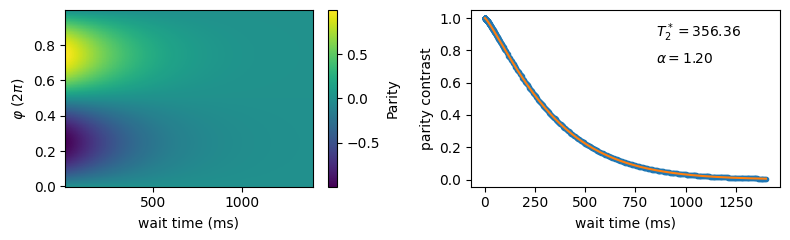

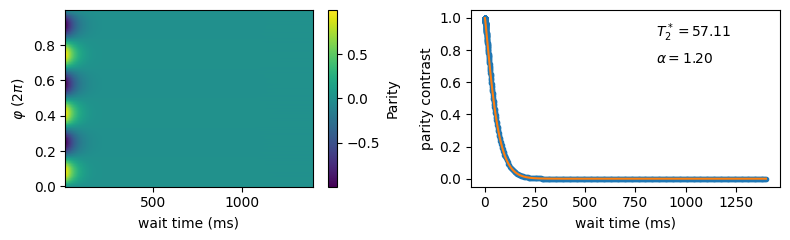

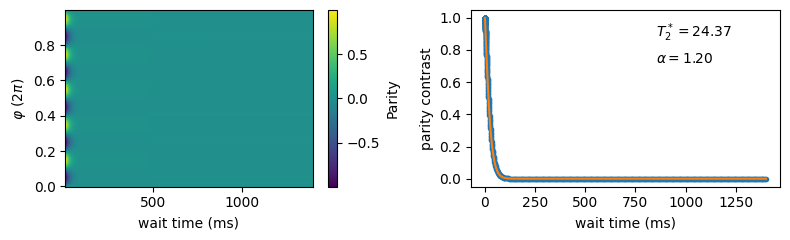

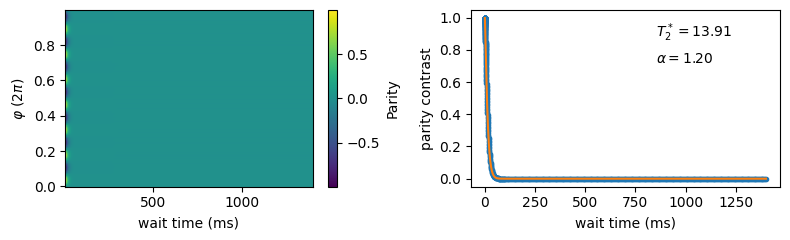

In [7]:
T2_z = np.zeros(4)
zcat_results = []
for s in range(4):

    fig, ax = plt.subplots(1,2,figsize=(8,2.5))
    pcm = ax[0].pcolormesh(t, np.arange(300)/300, zcatdecay[s][0])
    plt.colorbar(pcm, ax=ax[0], label='Parity')
    ax[0].set_xlabel('wait time (ms)')
    ax[0].set_ylabel(r'$\varphi$ ($2\pi$)')
    
    y = contrast(zcatdecay[s][0])
    ax[1].plot(t, y, '.')
    result = exp_model.fit(y, t=t, params=params)
    zcat_results.append(result)
    
    ax[1].plot(t, result.best_fit)
    T2_z[s] = result.params['T2star']
    ax[1].text(0.6, 0.85, r'$T_2^*=$%.2f' % result.params['T2star'], transform=ax[1].transAxes)
    ax[1].text(0.6, 0.7, r'$\alpha = $%.2f' % result.params['alpha'], transform=ax[1].transAxes)
    ax[1].set_xlabel('wait time (ms)')
    ax[1].set_ylabel('parity contrast')
    plt.tight_layout()

## x-cats

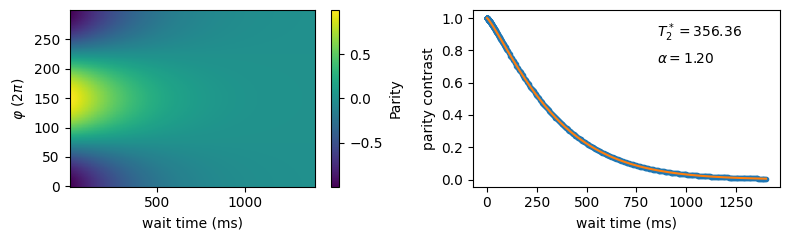

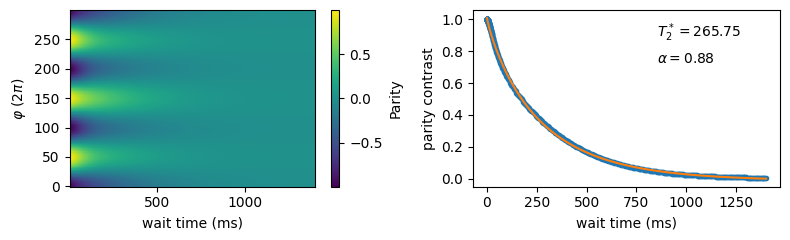

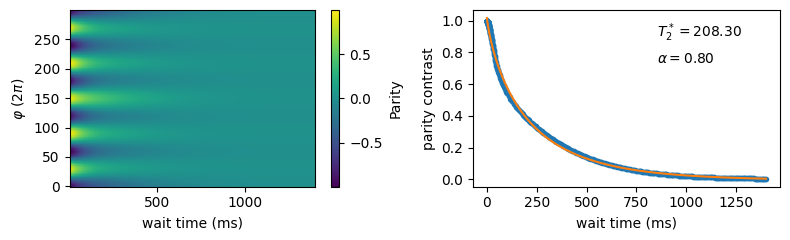

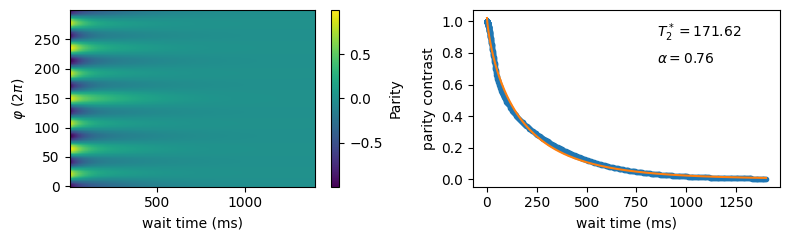

In [8]:
T2_x = np.zeros(4)
xcat_results = []
for s in range(4):

    fig, ax = plt.subplots(1,2,figsize=(8,2.5))
    pcm = ax[0].pcolormesh(t, np.arange(300), xcatdecay[s][0])
    plt.colorbar(pcm, ax=ax[0], label='Parity')
    ax[0].set_xlabel('wait time (ms)')
    ax[0].set_ylabel(r'$\varphi$ ($2\pi$)')
    
    y = contrast(xcatdecay[s][0])
    ax[1].plot(t, y, '.')
    result = exp_model.fit(y, t=t, params=params)
    xcat_results.append(result)
    
    ax[1].plot(t, result.best_fit)
    T2_x[s] = result.params['T2star']
    ax[1].text(0.6, 0.85, r'$T_2^*=$%.2f' % result.params['T2star'], transform=ax[1].transAxes)
    ax[1].text(0.6, 0.7, r'$\alpha = $%.2f' % result.params['alpha'], transform=ax[1].transAxes)
    ax[1].set_xlabel('wait time (ms)')
    ax[1].set_ylabel('parity contrast')
    plt.tight_layout()

In [9]:
import scipy.optimize 

Text(0, 0.5, '$1/T_2^*$ (1/s)')

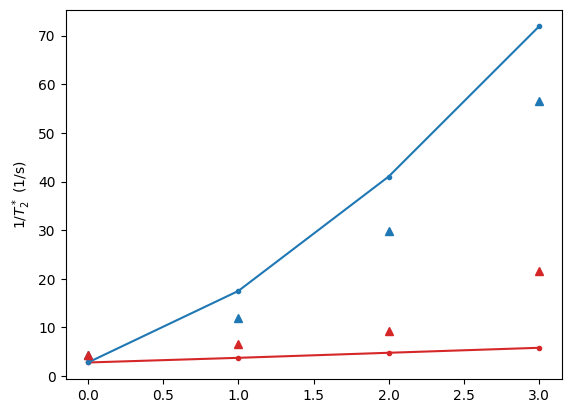

In [10]:
T2_zdata = np.flip(np.array([17.7, 33.5, 83.7, 233]))*1e-3
T2_xdata = np.flip(np.array([46.19, 107.7, 150.8, 233]))*1e-3

plt.plot(1/T2_x*1e3, color='tab:red', marker='.', ls='-')
plt.plot(1/T2_z*1e3, color='tab:blue', marker='.', ls='-')

plt.plot(1/T2_zdata, '^')
plt.plot(1/T2_xdata, '^', color='tab:red')

plt.ylabel(r'$1/T_2^*$ (1/s)')

## Simulate m=1 ramsey

C:\Users\Arjen Vaartjes\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Arjen Vaartjes\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Arjen Vaartjes\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Arjen Vaartjes\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Arjen Vaartjes\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Arjen Vaartjes\anaconda3\lib\si

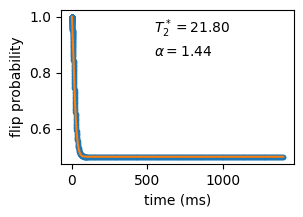

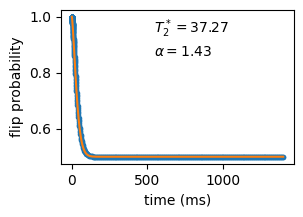

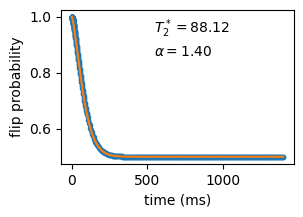

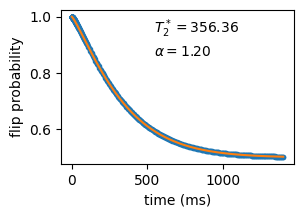

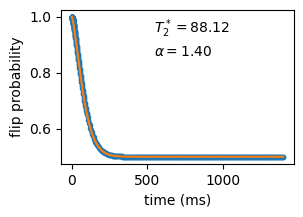

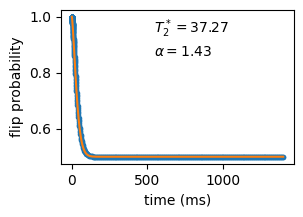

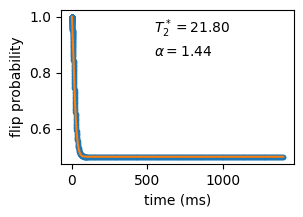

In [11]:
T2_so2 = np.zeros(7)
ind=-1
for i, m in enumerate(range(-7//2, 5//2 + 1)):
    fig, ax = plt.subplots(1,1, figsize=(3,2))
    ket = np.zeros(int(2 * I[ind].I + 1))
    ket[i] = 1 / np.sqrt(2)
    ket[i+1] = 1 / np.sqrt(2)
    y = I[ind].rho(ket).T @ decayify(ket)
    result = exp_model.fit(y, t=t, params=params)
    plt.plot(t, y, '.')
    plt.plot(t, result.best_fit)
    plt.text(0.4, 0.85, r'$T_2^*=$%.2f' % result.params['T2star'], transform=ax.transAxes)
    plt.text(0.4, 0.7, r'$\alpha = $%.2f' % result.params['alpha'], transform=ax.transAxes)
    
    T2_so2[i] = result.params['T2star']
    plt.xlabel('time (ms)')
    plt.ylabel('flip probability')

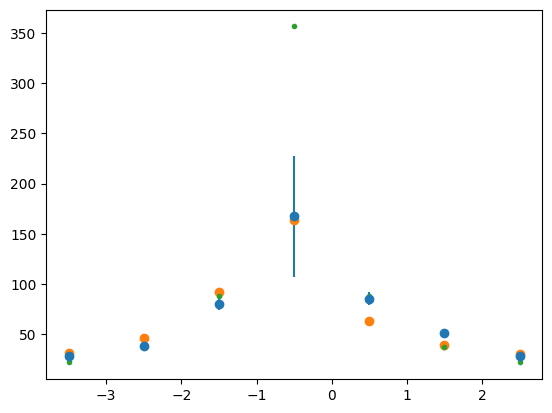

In [12]:
T2s_data = np.array([27.77, 37.79, 80.18, 167.17, 85.43, 51.09, 28.37]) # T2s dataset
T2s_err = np.array([0.00235, 0.002821, 0.00605, 0.0603, 0.00664, 0.00298, 0.00405])*1e3

T2s_data_sean = np.array([31.159682814887873,     46.070579515374575,     91.48661806739129,     163.58312692503782,     62.99113310727623,     39.11081759947726,     29.90245686352844])

plt.errorbar(np.arange(7)-3.5, T2s_data, T2s_err, ls='none', marker='o')
plt.plot(np.arange(7)-3.5, T2s_data_sean, ls='none', marker='o')
plt.plot(np.arange(7)-3.5, T2_so2, '.')

## Fit m=1 ramsey and z cats

### process m=1 ramsey data

In [13]:
qc.set_data_root_folder(r"C:\Users\Arjen Vaartjes\UNSW\Scarlett - General\data") # file location
data_T2 = qc.load_data(r'2024-01-01\#005_ionized-nmr-ramsey_20-26-23')

#if qc.load_data() doesn't work, try qc.legacy_import(). load_data is a depricated function in newer versions of QCodes

Data root folder set to C:\Users\Arjen Vaartjes\UNSW\Scarlett - General\data


In [14]:
NMR_transitions = {
    0: r"$-7/2 \leftrightarrow -5/2$",
    1: r"$-5/2 \leftrightarrow -3/2$",
    2: r"$-3/2 \leftrightarrow -1/2$",
    3: r"$-1/2 \leftrightarrow +1/2$",
    4: r"$+1/2 \leftrightarrow +3/2$",
    5: r"$+3/2 \leftrightarrow +5/2$",
    6: r"$+5/2 \leftrightarrow +7/2$"
}

T2_dict = {}

tau = data_T2["Wait_Time_0_0_0"][0][0]

### process z-cat data

In [15]:
data_z_cat_lifetime_7 = qc.load_data(r'2023-12-29\#012_ionized-cat-coherence-generalized-ramsey_17-49-09') # 7/2 -7/2 inside
data_z_cat_lifetime_5 = qc.load_data(r'2023-12-31\#009_ionized-cat-coherence-generalized-ramsey_13-46-19') # 5/2 -5/2 inside
data_z_cat_lifetime_3 = qc.load_data(r'2023-12-31\#008_ionized-cat-coherence-generalized-ramsey_11-25-47') # 3/2 -3/2 inside
data_z_cat_lifetime_1 = qc.load_data(r'2023-12-31\#015_ionized-cat-coherence-generalized-ramsey_18-59-39') # 1/2 -1/2 inside

data_z_cat = [data_z_cat_lifetime_7, data_z_cat_lifetime_5, data_z_cat_lifetime_3, data_z_cat_lifetime_1]

# Evaluate State probabilities

cat_list_dict = {
    "0" : "-7/2 to +7/2", 
    "1" : "-5/2 to +5/2", 
    "2" : "-3/2 to +3/2", 
    "3" : "-1/2 to +1/2", }
filter_outside_subspace = True
lifetimes = []
for data_index in range(len(data_z_cat)):    
    data = data_z_cat[data_index]
    num_esr_lines = len(data["ESR_up_proportions_0_0_0_0_0_0"][0][0][0])
    state_probabilities = np.zeros((len(data['Wait_Time_0_0_0'][0][0]),
                                    len(data["ESR_up_proportions_0_0_0_0_0_0"][0][0][0])))
    state_probabilities_std = np.zeros(np.shape(state_probabilities))
    
    exp_values_Iz =  np.zeros((len(data['Wait_Time_0_0_0'][0][0])))
    exp_values_Iz_std = np.zeros(np.shape(exp_values_Iz))
    
    num_reps = len(data['ESR_up_proportions_0_0_0_0_0_0'][0] )
    
    num_samples = len(data["ESR_up_proportions_0_0_0_0_0_0"][0][0][0][0])
    Iz = qt.jmat(7/2, "z")
    Iz_diagonal = np.real(np.diag(Iz))
    
    for i in range(len(data['Wait_Time_0_0_0'][0][0])):
        state_list_k = np.concatenate( [np.argmax(data['ESR_up_proportions_0_0_0_0_0_0'][0][j][i], axis = 0)\
                              for j in range(len(data['ESR_up_proportions_0_0_0_0_0_0'][0]))])
        state_list_k_filtered = [n for n in state_list_k if (n<=(num_esr_lines-data_index-1) and  n>=(data_index))]
        if filter_outside_subspace == True:
#             if (len(state_list_k) != len(state_list_k_filtered)): print("Data Filtered")
            state_list_k = state_list_k_filtered
        for k in range(num_esr_lines):
            state_probabilities[i][k] = np.sum([state_list_k] == np.array([k]*len(state_list_k)))/len(state_list_k)
            state_probabilities_std[i][k] =\
                np.std([state_list_k] == np.array([k]*len(state_list_k)))/np.sqrt(len(state_list_k))
        exp_values_Iz[i] = np.sum(Iz_diagonal[[meas for meas in state_list_k]])/len(state_list_k)
        exp_values_Iz_std[i] = np.std(Iz_diagonal[[meas for meas in state_list_k]])/np.sqrt(len(state_list_k))


    lifetimes.append({
        "State Probabilities" : state_probabilities,
        "State Probabilities Error" : state_probabilities_std,
        "Wait time" : data['Wait_Time_0_0_0'][0][0],
        "I_z" : exp_values_Iz,
        "I_z Error": exp_values_Iz_std,
        "Artificial Detuning": data["Artificial_Detuning_1"][0]
    }
    )

In [16]:
def generate_T2_z(exponents, plot=False):
    """
    Generate T2 decay times for the z-component based on given exponents.

    This function fits an exponential sine model to the state probability data for different wait times,
    using fixed exponents. It returns the fitted T2 decay times and their corresponding errors. 
    Optionally, it can plot the fit results.

    Parameters:
    exponents (list or numpy array): The exponents for the decay model, one for each state probability set.
    plot (bool, optional): If True, plots the fit results for each state probability set. Default is False.

    Returns:
    tuple: A tuple containing:
        - T2s (numpy array): The fitted T2 decay times.
        - T2s_err (numpy array): The standard errors of the fitted T2 decay times.
    """
    T2s = np.zeros(len(lifetimes))
    T2s_err = np.zeros(len(lifetimes))
    for s in range(len(lifetimes)):
        tau = lifetimes[s]["Wait time"]
        y = lifetimes[s]["State Probabilities"][:, s]

        osc_model = Model(ExponentialSineFit)
        params = Parameters()
        params.add('tau', value=0.1, min=0.01, max=0.4)
        params.add('amplitude', value=0.5, min=0.4, max=0.6)
        params.add('frequency', value=80/(s+1), min=10, max=120)
        params.add('phase_offset', value=0, min=-np.pi, max=np.pi)
        params.add('offset', value=0.5, min=0.4, max=0.6)
        params.add('alpha', value=exponents[s], min=0.5, max=2.5, vary=False)  #fix exponents

        result = osc_model.fit(y, t=tau, params=params)
        T2s[s] = result.params['tau']
        T2s_err[s] = result.params['tau'].stderr
        
        if plot:
            plt.figure(figsize=(3,2))
            plt.plot(tau*1e3, result.best_fit)
            plt.plot(tau*1e3, y, '.')
            plt.title(r'Spin %d/2'% ((4-s)*2-1))
            plt.xlabel('Wait time (ms)')
            plt.ylabel('flip probability')
        
    return T2s, T2s_err

(array([0.01560382, 0.0309247 , 0.07585109, 0.20650354]),
 array([0.00146257, 0.00237677, 0.00637418, 0.02650127]))

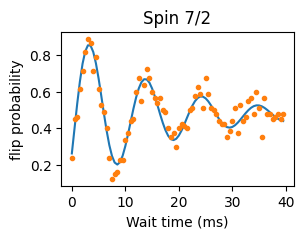

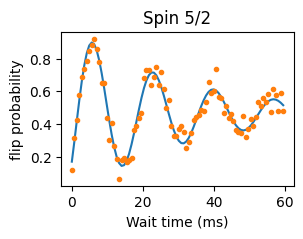

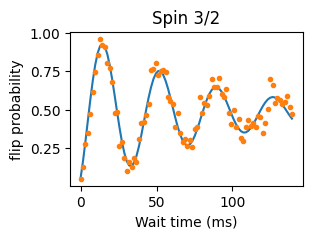

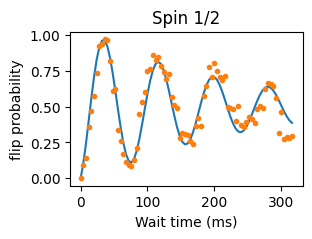

In [17]:
generate_T2_z([1,1,1,1], plot=True)

The idea of the fitting is to optimize T2* values for both the m=1 ramseys and z-cat ramseys:

\begin{itemize}
    \item Pick values for T2*_m, T2*_e, exponent_m, exponent_e
    \item generate a set of T2* values from the Ramsey measurement data (both m=1 Ramsey and z-cats) using fixed values for exponent_m, exponent_e
    \item simulate a set of T2* values with values for T2*_m, T2*_e, exponent_m, exponent_e (both m=1 and z-cats)
    \item concatenate T2* arrays for m=1 and z-cats, both for data and simulation
    \item minimize residual = (data - simulation) with free parameters T2*_m, T2*_e, exponent_m, exponent_e
\end{itemize}

### fitting helpers

In [18]:
exp_model = Model(exponential_decay)
params = Parameters()
params.add('T2star', value=50.0, min=0.1, max=800.0)
params.add('amplitude', value=1.0, min=0.1)
params.add('offset', value=0.0)
params.add('alpha', value=1.5, min=0.1, max=2.3)

# fitting helpers

def calculate_so2_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=False):
    """
    Calculate the T2* and exponents for the SO2-ramseys based on given parameters.

    This function uses a high spin model to simulate Ramsey experiments and fit the resulting data to 
    extract T2* times and their exponents for the SO2 ramseys. Optionally, it can plot the 
    fit results for each state.

    Parameters:
    t2star_m (float): T2* time for the magnetic noise.
    t2star_e (float): T2* time for the electric noise.
    exponent_m (float): Exponent for the magnetic noise decay.
    exponent_e (float): Exponent for the electric noise decay.
    plot (bool, optional): If True, plots the fit results for each state. Default is False.

    Returns:
    tuple: A tuple containing:
        - T2_so2 (numpy array): The fitted T2* times for the SO2 ramseys.
        - T2_so2_alpha (numpy array): The exponents for the fitted T2* times.
    """
    for s in range(len(I)):
        model = HighSpinModel(I[s]) 
        model.T2Mstar = t2star_m
        model.T2Estar = t2star_e
        model.alphaM = exponent_m
        model.alphaE = exponent_e
        modRam = model.Ramsey(t, 0)
        decayify = lambda state: I[s].rho(state)[:, np.newaxis] * modRam

    T2_so2 = np.zeros(7)
    T2_so2_alpha = np.zeros(7)
    ind=-1
    for i, m in enumerate(range(-7//2, 5//2 + 1)):
        
        ket = np.zeros(int(2 * I[ind].I + 1))
        ket[i] = 1 / np.sqrt(2)
        ket[i+1] = 1 / np.sqrt(2)
        y = I[ind].rho(ket).T @ decayify(ket)
        result = exp_model.fit(y, t=t, params=params)
        T2_so2[i] = result.params['T2star']
        T2_so2_alpha[i] = result.params['alpha']
        
        if plot:
            fig, ax = plt.subplots(1,1, figsize=(3,2))
            ax.plot(t, y, '.')
            ax.plot(t, result.best_fit)
            ax.text(0.4, 0.85, r'$T_2^*=$%.2f' % result.params['T2star'], transform=ax.transAxes)
            ax.text(0.4, 0.7, r'$\alpha = $%.2f' % result.params['alpha'], transform=ax.transAxes)
            ax.set_xlabel('wait time (ms)')
            ax.set_ylabel('decay')
        
    return T2_so2, T2_so2_alpha

def calculate_z_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=False):
    """
    Calculate the T2* and exponents for the z-cat-ramseys based on given parameters.

    This function uses a high spin model to simulate Ramsey experiments and fit the resulting data to 
    extract T2* times and their exponents for the z-cat ramseys. Optionally, it can plot the 
    fit results for each state.

    Parameters:
    t2star_m (float): T2* time for the magnetic noise.
    t2star_e (float): T2* time for the electric noise.
    exponent_m (float): Exponent for the magnetic noise decay.
    exponent_e (float): Exponent for the electric noise decay.
    plot (bool, optional): If True, plots the fit results for each state. Default is False.

    Returns:
    tuple: A tuple containing:
        - T2_so2 (numpy array): The fitted T2* times for the z-cats.
        - T2_so2_alpha (numpy array): The exponents for the fitted T2* times.
    """
    T2_z = np.zeros(len(I))
    zcatdecay = [[] for _ in range(len(I))]
    for s in range(len(I)):
        model = HighSpinModel(I[s]) 
        model.T2Mstar = t2star_m
        model.T2Estar = t2star_e
        model.alphaM = exponent_m
        model.alphaE = exponent_e
        modRam = model.Ramsey(t, 0)
        decayify = lambda state: I[s].rho(state)[:, np.newaxis] * modRam

        zcat = np.zeros(int(2 * I[s].I + 1))
        zcat[0] = 1 / np.sqrt(2)
        zcat[-1] = 1 / np.sqrt(2)

        zcatdecay[s].append(I[s].paritymeas(decayify(zcat), 'z'))

        y = contrast(zcatdecay[s][0])
        result = exp_model.fit(y, t=t, params=params)
        T2_z[s] = result.params['T2star']
        if plot:
            fig, ax = plt.subplots(1,2,figsize=(8,2.5))
            pcm = ax[0].pcolormesh(t, np.arange(300), zcatdecay[s][0])
            plt.colorbar(pcm, ax=ax[0], label='Parity')
            ax[0].set_xlabel('wait time (ms)')
            ax[0].set_ylabel(r'$\varphi$ ($2\pi$)')

            ax[1].plot(t, y, '.')
            ax[1].plot(t, result.best_fit)

            ax[1].text(0.6, 0.85, r'$T_2^*=$%.2f' % result.params['T2star'], transform=ax[1].transAxes)
            ax[1].text(0.6, 0.7, r'$\alpha = $%.2f' % result.params['alpha'], transform=ax[1].transAxes)
            ax[1].set_xlabel('wait time (ms)')
            ax[1].set_ylabel('parity contrast')
            plt.tight_layout()
        
    return T2_z
    
def generate_T2_data(exponents, plot=False):
    """
    Generate T2 decay data and fit T2 times based on given exponents.

    This function fits an exponential sine model to filtered flip probability data for different wait times,
    using fixed exponents. It returns the fitted T2 decay times and their corresponding errors.
    Optionally, it can plot the fit results.

    Parameters:
    exponents (list or numpy array): The exponents for the decay model, one for each state probability set.
    plot (bool, optional): If True, plots the fit results for each state probability set. Default is False.

    Returns:
    tuple: A tuple containing:
        - T2s (numpy array): The fitted T2 decay times.
        - T2s_err (numpy array): The standard errors of the fitted T2 decay times.
    """
    T2s = np.zeros(7)
    T2s_err = np.zeros(7)
    
    for s in range(len(data_T2["target_state_0"])):
        
        osc_model = Model(ExponentialSineFit)
        params = Parameters()
        params.add('tau', value=0.1, min=0.01, max=0.4)
        params.add('amplitude', value=0.5, min=0.4, max=0.6)
        params.add('frequency', value=40, min=30, max=80)
        params.add('phase_offset', value=np.pi/2, min=-np.pi, max=np.pi)
        params.add('offset', value=0.5, min=0.4, max=0.6)
        params.add('alpha', value=exponents[s], min=0.5, max=2.5, vary=False)  #fix exponents
        
        data_subspace = data_T2["filtered_flip_probability_0_1_0_0_0_1"][s].mean(0)
        tau = data_T2["Wait_Time_0_0_0"][0][s]
        result = osc_model.fit(data_subspace, t=tau, params=params)
        T2s[s] = result.params['tau']
        T2s_err[s] = result.params['tau'].stderr
        
        if plot:
            plt.figure(figsize=(3,2))
            plt.plot(tau, result.best_fit)
            plt.plot(tau, data_subspace, '.')
            plt.xlabel('wait time (ms)')
            plt.ylabel('parity contrast')
            plt.title(NMR_transitions[s])

    return T2s, T2s_err

In [19]:
T2_sim, alphas = calculate_so2_T2_exponents(t2star_m=300, t2star_e=1000, exponent_m=1.5, exponent_e=1.1)
T2_data, T2_err = generate_T2_data(alphas)

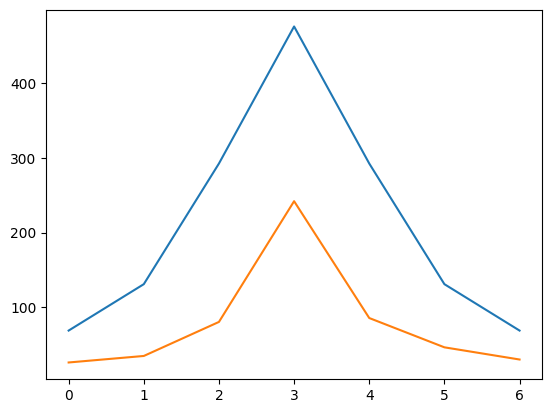

In [20]:
#example for m=1 ramseys
plt.plot(T2_sim)
plt.plot(T2_data*1e3)

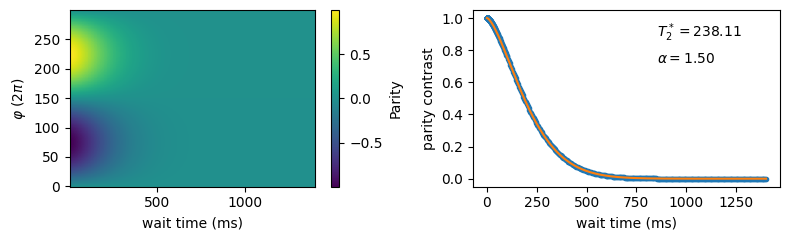

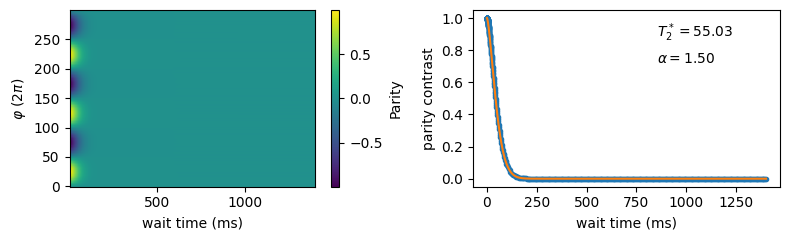

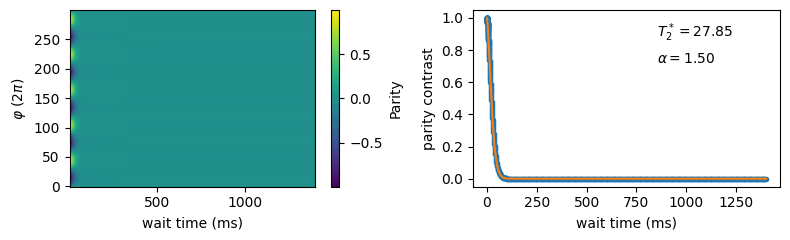

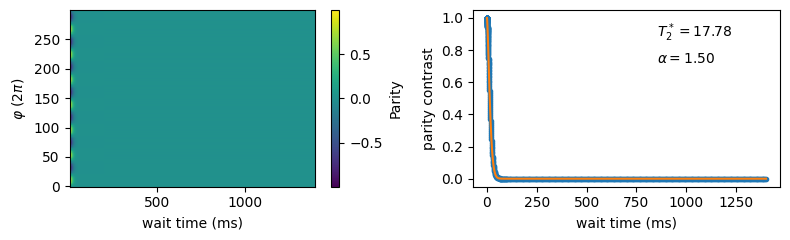

In [21]:
# z-cats example
T2_sim = calculate_z_T2_exponents(t2star_m=150, t2star_e=100, exponent_m=1.5, exponent_e=1.1, plot=True)

### fit

In [113]:
# Define a wrapper function for lmfit
def residual(params):
    t2star_m = params['T2_m']
    t2star_e = params['T2_e'] 
    exponent_m = params['exponent_m'] 
    exponent_e = params['exponent_e']
    
    #so2
    T2_model, alphas = calculate_so2_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e)
    T2_data, T2_err = generate_T2_data(alphas)
    
    zT2_model = calculate_z_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e)
    T2_z_data, T2_z_err = generate_T2_z(np.repeat(exponent_m, 4), plot=False)
    
    T2_z_data[-1] = T2_data[3]  # same experiment?
    T2_z_err[-1] = T2_err[3]*1e-3  # same experiment?
    
    # concatenate m=1 ramsey and z-cat states arrays
    model = np.concatenate([T2_model, zT2_model])
    data = np.concatenate([T2_data, np.flip(T2_z_data)])
    
    return (model - data*1e3)

# Create lmfit Parameters object
fit_params = Parameters()
fit_params.add('T2_m', value=200, min=120, max=250)
fit_params.add('T2_e', value=400, min=100, max=1600)
fit_params.add('exponent_m', value=1.6, min=1.3, max=1.7)
fit_params.add('exponent_e', value=1, min=0.8, max=1.5)

# optimize (this can take a minute)
result = minimize(residual, fit_params, method='nelder_mead')

# Visualisation

C:\Users\Arjen Vaartjes\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Arjen Vaartjes\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Arjen Vaartjes\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Arjen Vaartjes\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Arjen Vaartjes\anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\Arjen Vaartjes\anaconda3\lib\si

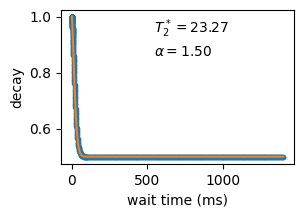

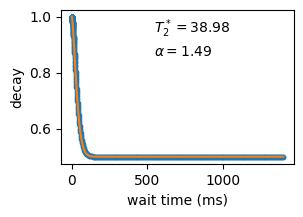

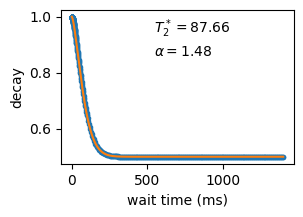

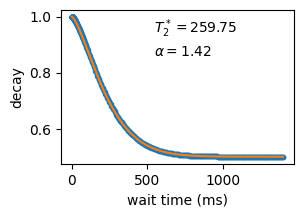

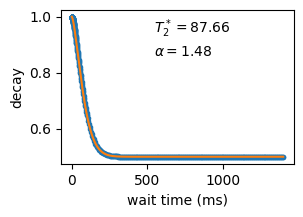

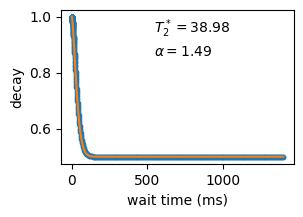

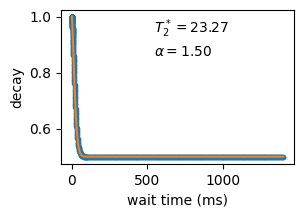

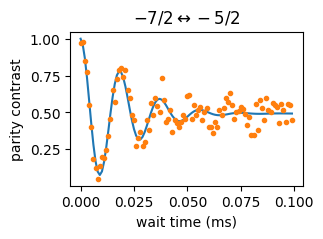

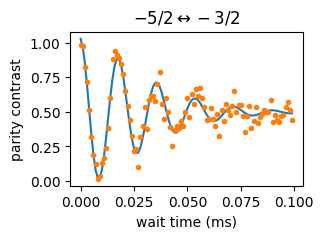

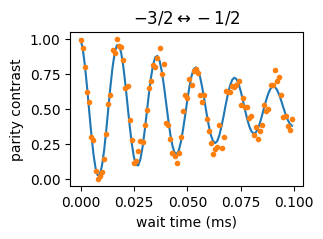

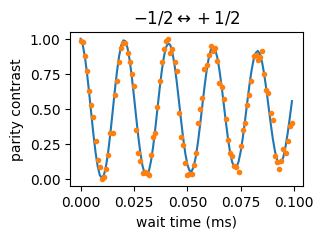

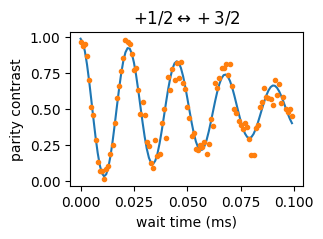

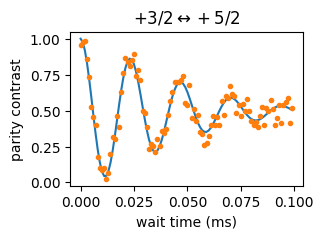

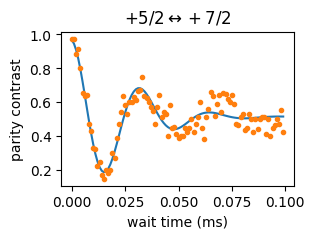

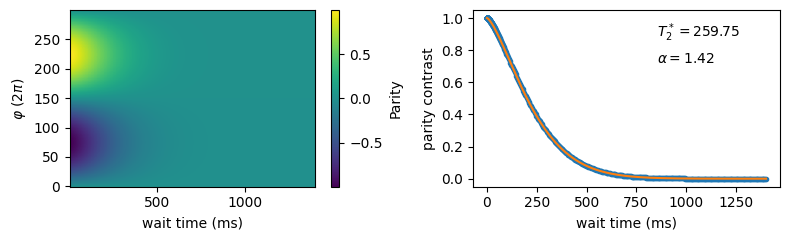

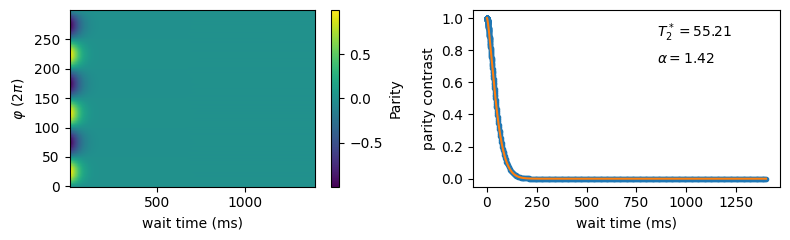

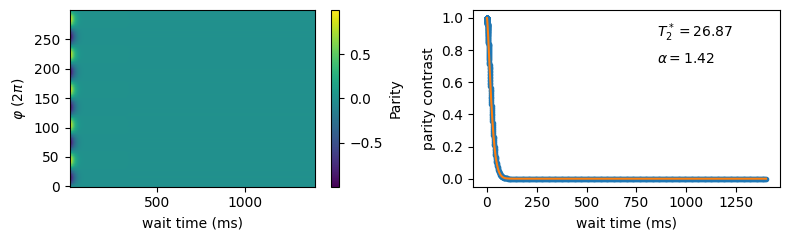

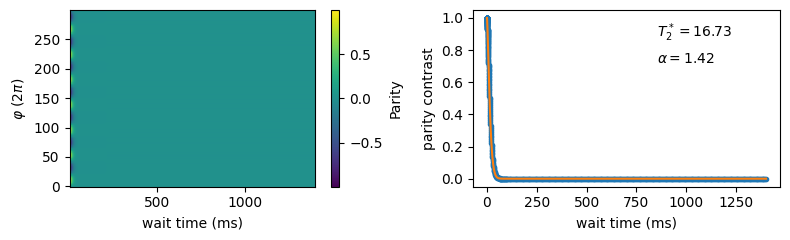

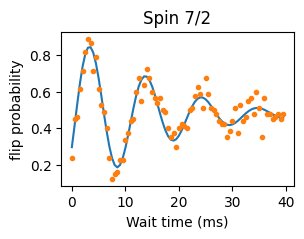

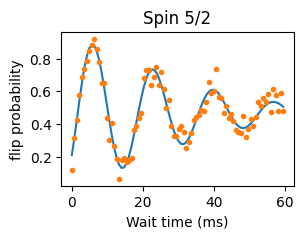

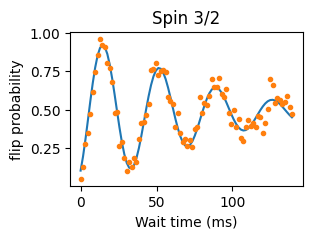

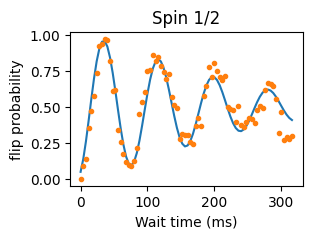

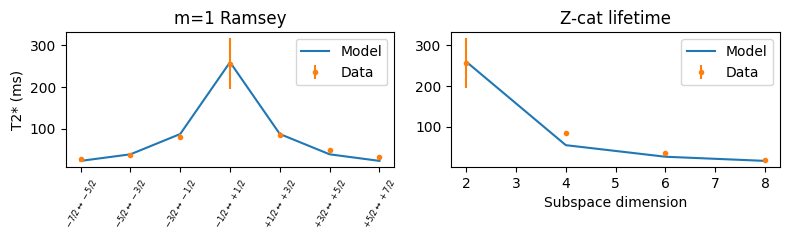

In [122]:
t2star_m = result.params['T2_m']
t2star_e = result.params['T2_e'] 
exponent_m = result.params['exponent_m'] 
exponent_e = result.params['exponent_e']

T2_model, alphas = calculate_so2_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=True)
T2_data, T2_err = generate_T2_data(alphas, plot=True)
T2_sim = calculate_z_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=True)
T2_z_data, T2_z_err = generate_T2_z(np.repeat(exponent_m, 4), plot=True)

T2s_err = np.array([0.00235, 0.002821, 0.00605, 0.0603, 0.00664, 0.00298, 0.00405])*1e3

T2_z_data[-1] = T2_data[3]
T2_z_err[-1] = T2s_err[3]*1e-3

fig, ax = plt.subplots(1,2,figsize=(8, 2.5))
ax[0].plot(np.arange(7), T2_model, label='Model')
ax[0].errorbar(np.arange(7), T2_data*1e3, T2s_err, marker='.', label='Data', ls='None')
ax[0].set_xticks(np.arange(7))
ax[0].set_xticklabels(NMR_transition_labels, fontsize = 6, rotation=60)
ax[0].set_title('m=1 Ramsey')
ax[0].legend()

plt.plot([2, 4, 6, 8], T2_sim, label='Model')
plt.errorbar([2, 4, 6, 8], np.flip(T2_z_data)*1e3, np.flip(T2_z_err)*1e3, marker='.', label='Data', ls='None')
plt.xlabel('Subspace dimension')
ax[0].set_ylabel('T2* (ms)')
plt.title('Z-cat lifetime')
plt.tight_layout()
plt.legend()

In [54]:
result

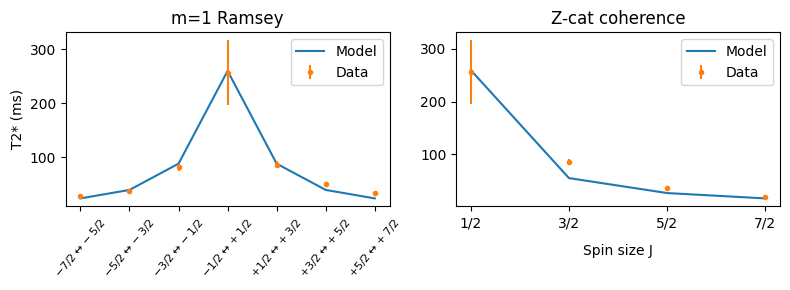

In [126]:
fig, ax = plt.subplots(1,2,figsize=(8, 3))
ax[0].plot(np.arange(7), T2_model, label='Model')
ax[0].errorbar(np.arange(7), T2_data*1e3, T2s_err, marker='.', label='Data', ls='None')
ax[0].set_xticks(np.arange(7))
ax[0].set_xticklabels(NMR_transition_labels, fontsize = 8, rotation=50)
ax[0].set_title('m=1 Ramsey')
ax[0].legend()

plt.plot(np.array([2, 4, 6, 8])/2-0.5, T2_sim, label='Model')
plt.errorbar(np.array([2, 4, 6, 8])/2-0.5, np.flip(T2_z_data)*1e3, np.flip(T2_z_err)*1e3, marker='.', label='Data', ls='None')
plt.xlabel('Spin size J', labelpad=10)
ax[1].set_xticks([0.5, 1.5, 2.5, 3.5])
ax[1].set_xticklabels(['1/2', '3/2', '5/2', '7/2'])
ax[0].set_ylabel('T2* (ms)')
plt.title('Z-cat coherence')
plt.tight_layout()
plt.legend()
plt.savefig("coherence_model_fit.png", dpi=1200)
plt.savefig("coherence_model_fit.svg", dpi=1200)